In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.preprocessing import MinMaxScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [3]:
Train_data1 = pd.read_csv(r"C:\Users\KIIT\Desktop\ExcelR Data science\Assignments\Logistic Regression\Titanic_train.csv")
Test_data = pd.read_csv(r"C:\Users\KIIT\Desktop\ExcelR Data science\Assignments\Logistic Regression\Titanic_test.csv")

In [9]:
def EDA(data):
    #print(data.head(5))
    print("sHAPE:",data.shape, "\n" )
    print("Info",data.info(), "\n" )
    print(data.describe(), "\n" )
    print("Missing Values:",data.isnull().sum(), "\n" )
    print("Duplicate Check:",data.duplicated().sum(), "\n" )
    Numerical_columns = data.select_dtypes(include='number')
    categorical_columns = data.select_dtypes(include='object')

    #checking the distribution of each numerical variable
    for column in Numerical_columns:
        #plt.figure(figsize=(6,4))
        sns.histplot(data = data, x = column,bins = 30, kde = True, color = 'orange', alpha = 0.7)
        plt.title(f"Histogram of {column}")
        plt.xlabel(f"{column}")
        plt.ylabel("Frequency")
        plt.show()

    #checking the distribution of each categorical variable
    # for column in categorical_columns:
    #     sns.barplot(data= data, x = column)
    #     plt.title(f"Barplot of {column}")
    #     plt.xlabel(f"{column}")
    #     plt.ylabel("Frequency")
    #     plt.show()
    
    correlation = Numerical_columns.corr()
    plt.title("Correlation matrix")
    heatmap = sns.heatmap(correlation, cmap = 'YlGnBu', annot = True, linewidth=.8)


In [10]:
Train_data1.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


sHAPE: (891, 12) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Info None 

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std

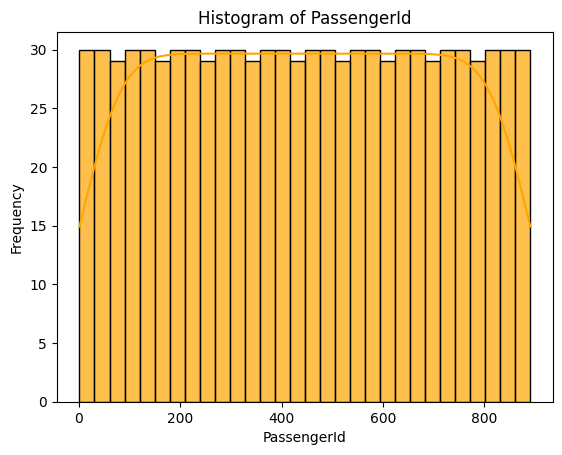

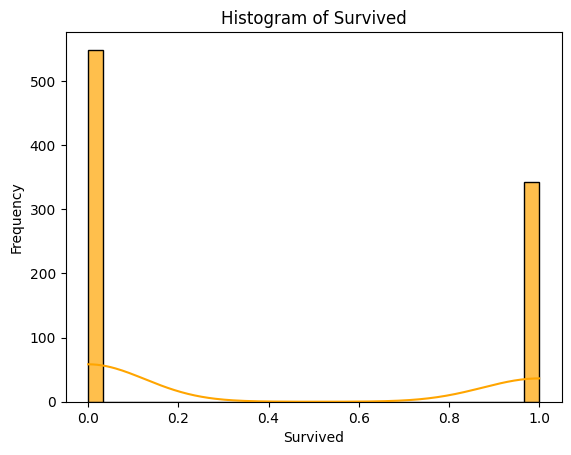

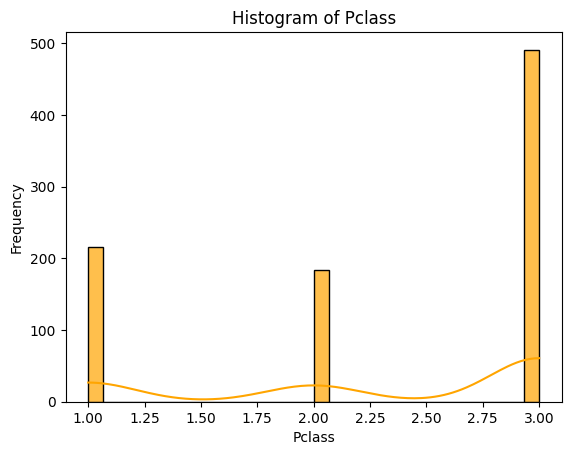

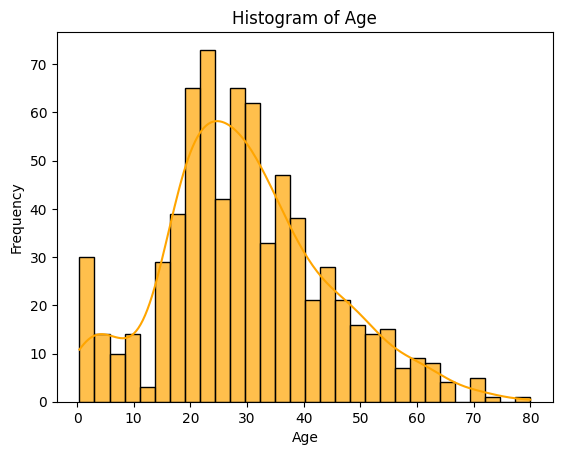

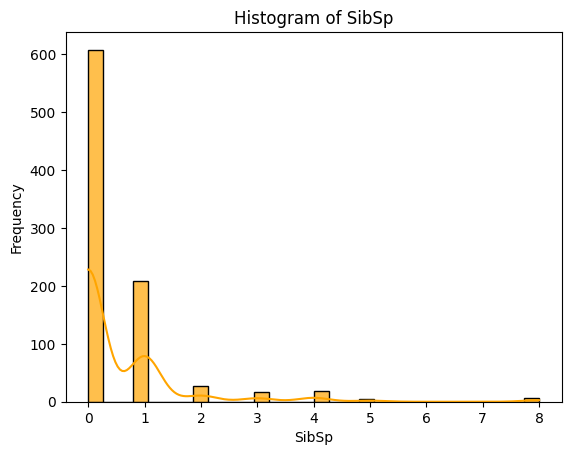

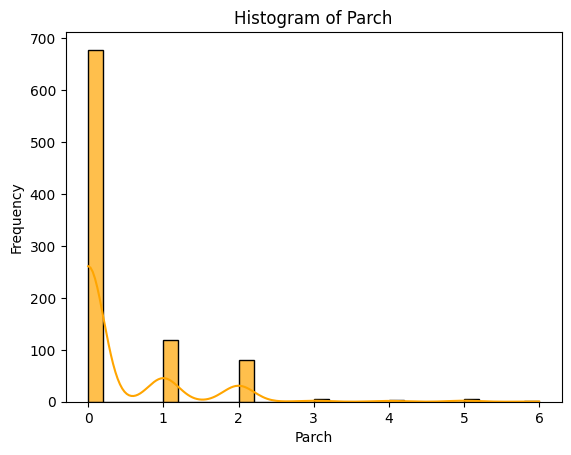

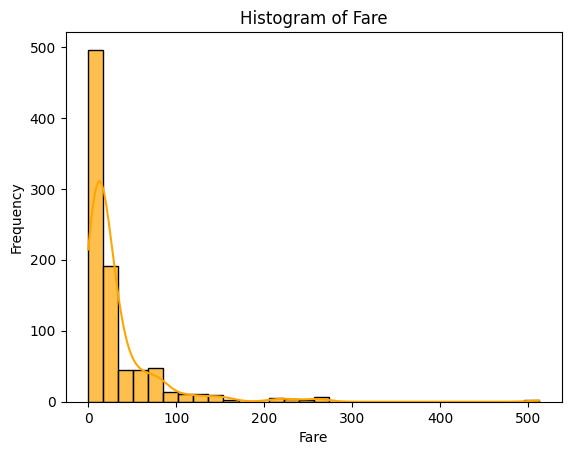

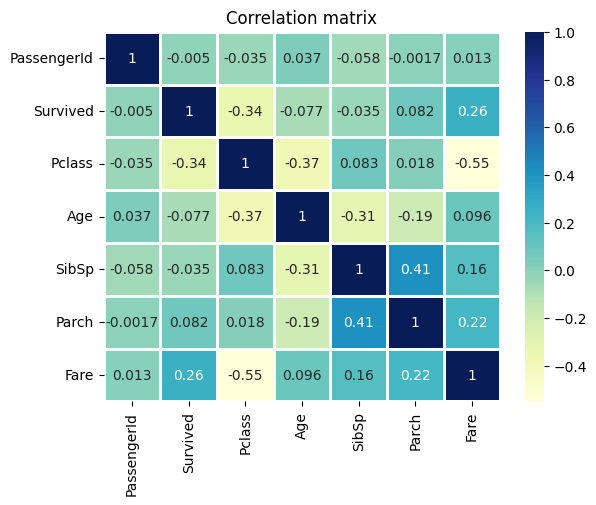

In [11]:
EDA(Train_data1)

__This is only the initial EDA, we will call the function again after preprocessing, feature engineering and outlier treatments__

In [58]:
def feature_engineering(data):
      #IMPUTATION
    #for AGE we can use median imputation as the data is not missing completely at random,
    #  Lets DROP cabin as it has 77% missing values and it is not required for prediction, 
    # lets use mode imputation for embarked as it has 2 missing values

    data['Age'] = data['Age'].fillna(data['Age'].median())
    data = data.drop(['Cabin','PassengerId','Name','Ticket'], axis=1)
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
    
    # Encoding
     #For gender we can use label encoding
    #For embarked we can use one hot encoding
  
    data = pd.get_dummies(data, columns=['Embarked', 'Sex'], drop_first=True)

    #Converting the boolean columns to numeric
    # Automatically convert all boolean columns to integers (0/1)
    bool_cols = data.select_dtypes(include=['bool']).columns
    data[bool_cols] = data[bool_cols].astype(int)

    return data

    
    


In [59]:
fe_trained = feature_engineering(Train_data1)

In [60]:
fe_trained.head(5)

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Sex_male
0,0,3,22.0,1,0,7.2500,0,1,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,1,0
3,1,1,35.0,1,0,53.1000,0,1,0
4,0,3,35.0,0,0,8.0500,0,1,1


In [62]:
def outlierdetection(data):
    column = [ 'Survived'	,'Pclass'	,'Age'	,'SibSp'	,'Parch'	,'Fare'	,'Embarked_Q'	,'Embarked_S'	,'Sex_male' ]

#visualizing for outliers in varible 
    for i in column: 
        plt.figure(figsize=(6,6))
        sns.color_palette = 'deep'
        sns.boxplot(data = data, y = i, linewidth=0.75)
        plt.title(f"Boxplot of {i}")
        plt.xlabel("frequency")
        plt.ylabel(f"{i}")
        plt.show()
    
    #detecting outliers in each varible 
    Q1 = data['Age'].quantile(0.25)
    Q3 = data['Age'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    age_outliers = data[(data['Age']<lower_bound) | (data['Age']> upper_bound)]
    return age_outliers





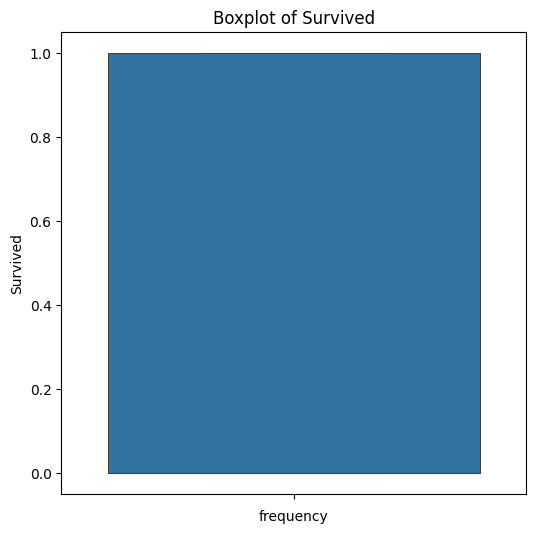

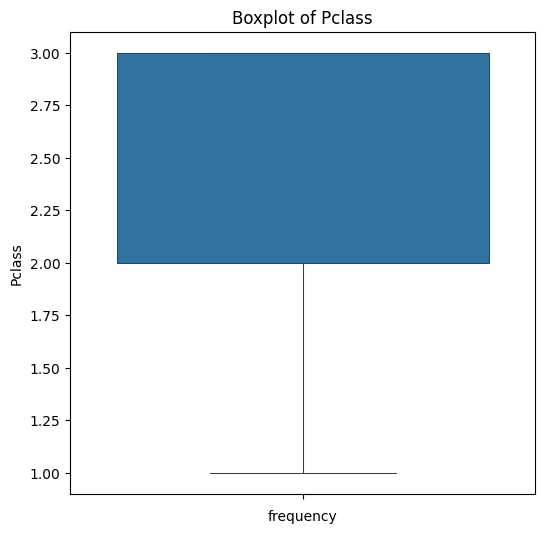

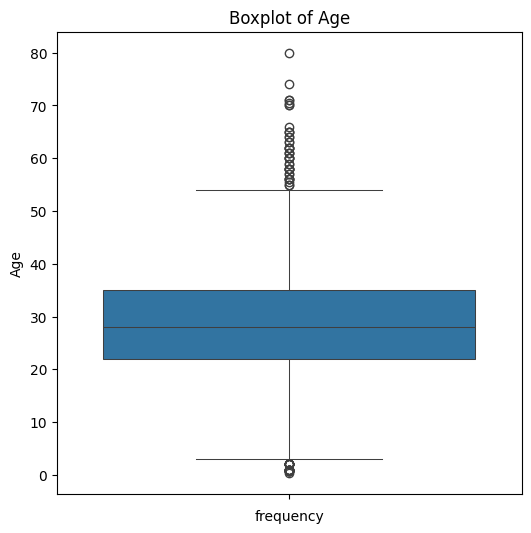

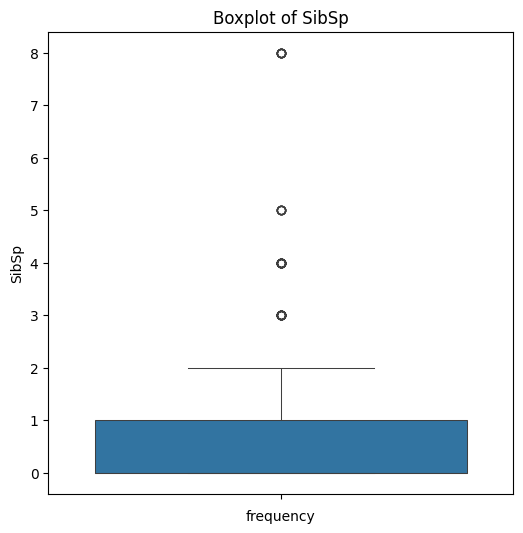

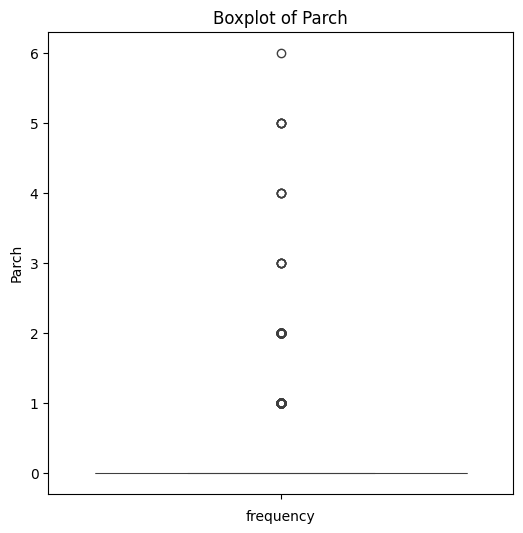

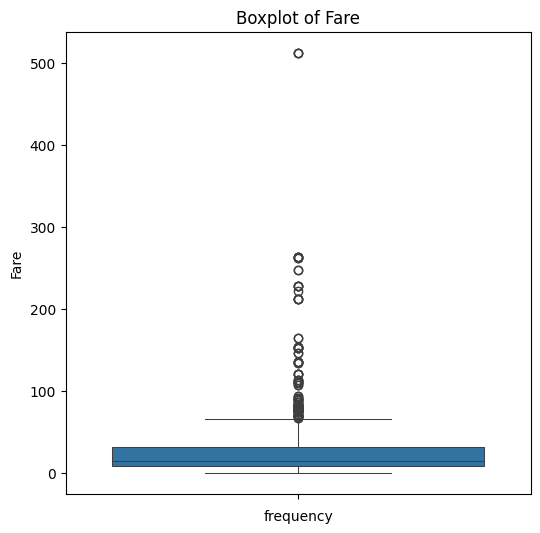

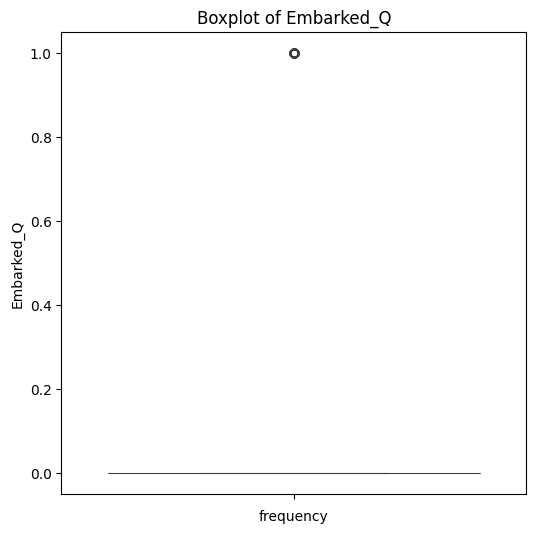

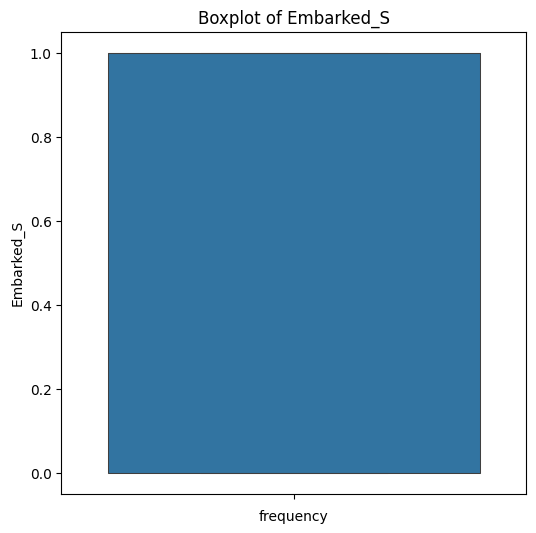

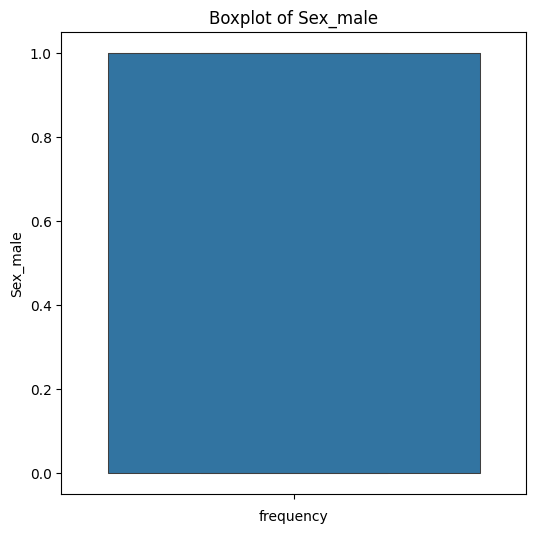

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Sex_male
7,0,3,2.00,3,1,21.0750,0,1,1
11,1,1,58.00,0,0,26.5500,0,1,0
15,1,2,55.00,0,0,16.0000,0,1,0
16,0,3,2.00,4,1,29.1250,1,0,1
33,0,2,66.00,0,0,10.5000,0,1,1
...,...,...,...,...,...,...,...,...,...
827,1,2,1.00,0,2,37.0042,0,0,1
829,1,1,62.00,0,0,80.0000,0,1,0
831,1,2,0.83,1,1,18.7500,0,1,1
851,0,3,74.00,0,0,7.7750,0,1,1


In [63]:
outliers_age = outlierdetection(fe_trained)
outliers_age

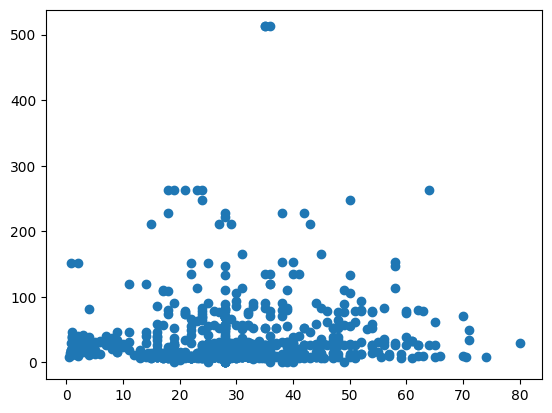

In [64]:
x = fe_trained['Age']
y = fe_trained['Fare']
plt.scatter(x,y)
plt.show()

__The outliers in age and fare combined is very less, and since age eventhough extreme, can help in finding distinct survival patterns and Fare whcih also vary can determine the wealth of an individual where a wealthy indiividual migh have had a higher probablity in survival__

    - Lets run the logistic regression model, check the error and evaluation metrics and then decide on future action

In [76]:
#MIN Max scaler to transform the Fare to a particular range to have an unbiased contribution
scaler = MinMaxScaler()
fe_trained['Age_scaled'] = scaler.fit_transform(fe_trained[['Age']])
fe_trained.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Sex_male,Fare_scaled,Age_scaled
0,0,3,22.0,1,0,7.2500,0,1,1,0.014151,0.271174
1,1,1,38.0,1,0,71.2833,0,0,0,0.139136,0.472229
2,1,3,26.0,0,0,7.9250,0,1,0,0.015469,0.321438
3,1,1,35.0,1,0,53.1000,0,1,0,0.103644,0.434531
4,0,3,35.0,0,0,8.0500,0,1,1,0.015713,0.434531


In [ ]:
#lets check for multicollinearity before proceding
def VIF(data):
    column = ['Pclass','Age_scaled','SibSp','Parch','Embarked_Q','Embarked_S','Sex_male','Fare_scaled']
    df = fe_trained[column]
    vif_data = pd.DataFrame() 
    vif_data['Feature'] = column
    vif_data['VIF'] = [vif(df.values, i) for i in range(df.shape[1])]
    return vif_data 


       Feature       VIF
0       Pclass  6.556351
1   Age_scaled  4.580385
2        SibSp  1.572827
3        Parch  1.627358
4   Embarked_Q  1.615590
5   Embarked_S  4.831593
6     Sex_male  3.122727
7  Fare_scaled  1.665540


From the VIF score we can conclude that only the Pclass have high multicollinearity, so we can either drop it or consider transforming it. 
    - Lets Transform it, since the Pclass is related to the Fare (High fare, different Pclass) lets transform it

sHAPE: (891, 11) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Embarked_Q   891 non-null    int32  
 7   Embarked_S   891 non-null    int32  
 8   Sex_male     891 non-null    int32  
 9   Fare_scaled  891 non-null    float64
 10  Age_scaled   891 non-null    float64
dtypes: float64(4), int32(3), int64(4)
memory usage: 66.3 KB
Info None 

         Survived      Pclass         Age       SibSp       Parch        Fare  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838    2.308642   29.361582    0.523008    0.381594   32.204208   
std      0.486

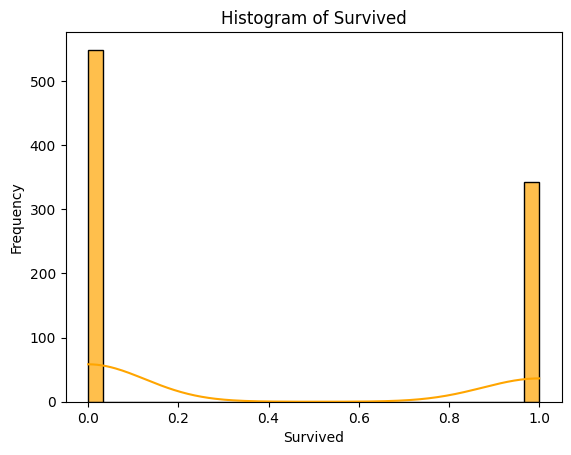

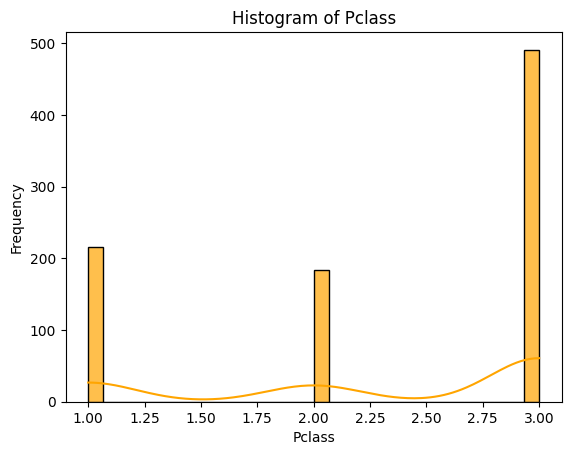

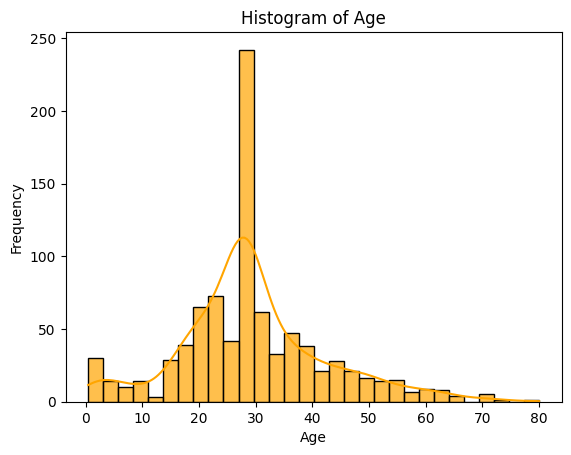

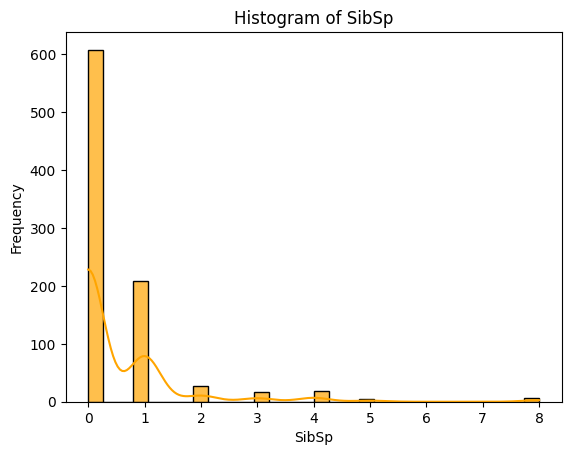

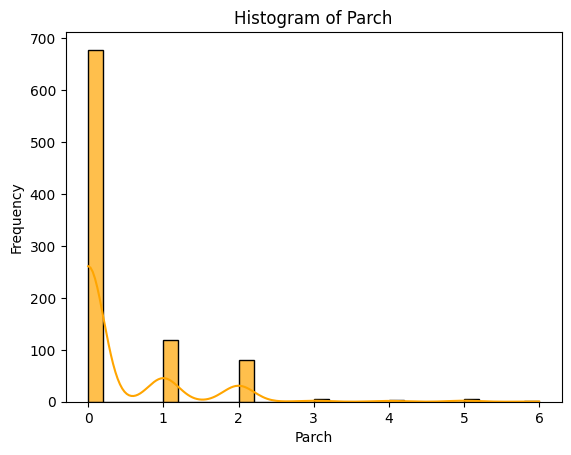

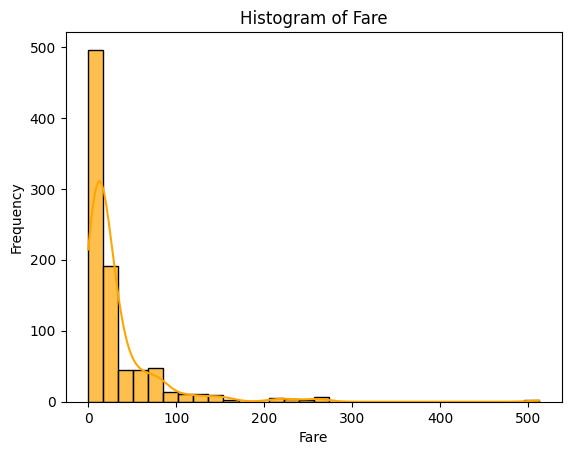

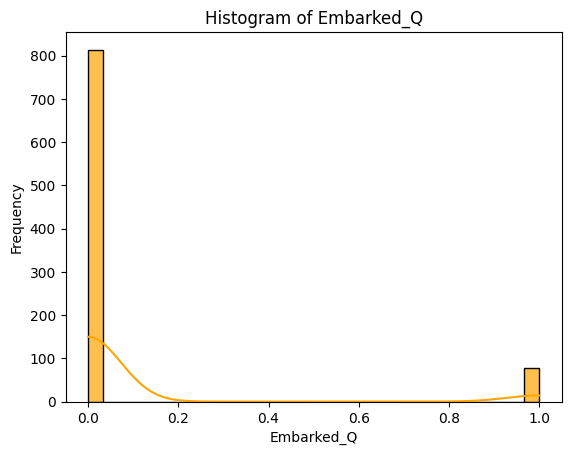

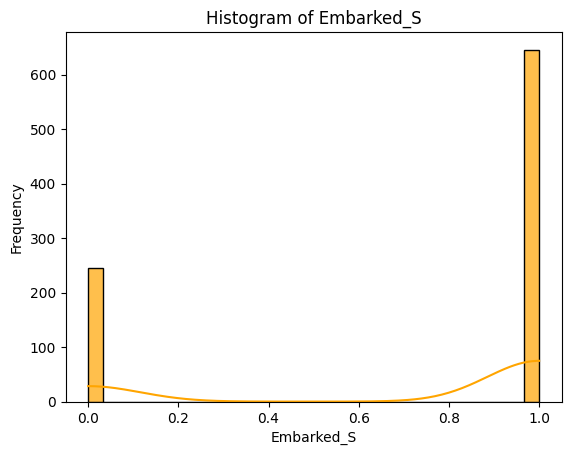

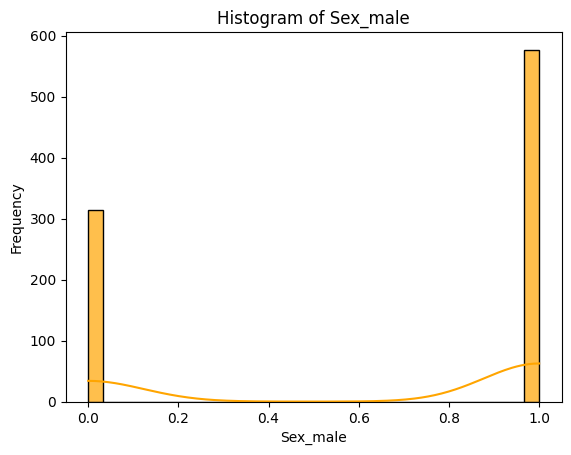

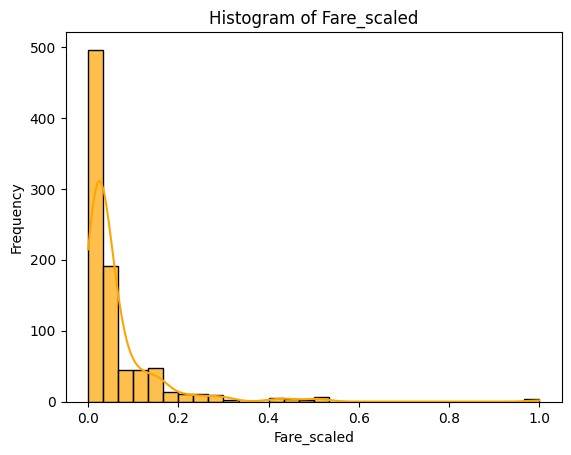

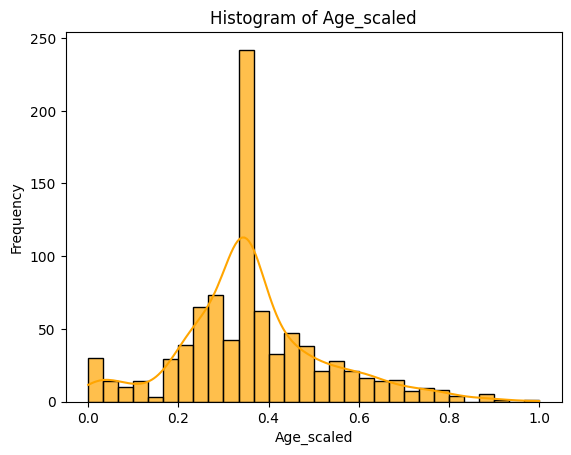

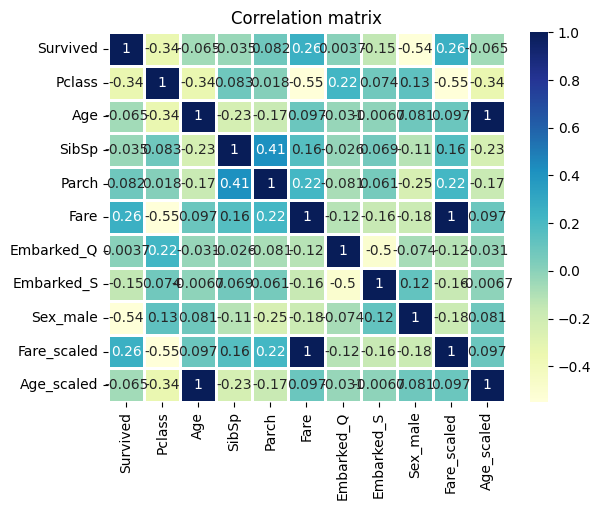

In [81]:
EDA(fe_trained)

In [92]:
data = pd.get_dummies(fe_trained, columns=['Pclass'], drop_first=True)

    #Converting the boolean columns to numeric
    # Automatically convert all boolean columns to integers (0/1)
bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)


In [95]:
data.head()

,Survived,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Sex_male,Fare_scaled,Age_scaled,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,0,1,1,0.014151,0.271174,0,1
1,1,38.0,1,0,71.2833,0,0,0,0.139136,0.472229,0,0
2,1,26.0,0,0,7.9250,0,1,0,0.015469,0.321438,0,1
3,1,35.0,1,0,53.1000,0,1,0,0.103644,0.434531,0,0
4,0,35.0,0,0,8.0500,0,1,1,0.015713,0.434531,0,1


In [94]:
column = ['Age_scaled','SibSp','Parch','Embarked_Q','Embarked_S','Sex_male','Fare_scaled','Pclass_2','Pclass_3']
df1 = data[column]
vif_data = pd.DataFrame() 
vif_data['Feature'] = column
vif_data['VIF'] = [vif(df1.values, i) for i in range(df1.shape[1])]
print(vif_data)

       Feature       VIF
0   Age_scaled  4.362399
1        SibSp  1.569011
2        Parch  1.625260
3   Embarked_Q  1.570067
4   Embarked_S  4.854850
5     Sex_male  3.034618
6  Fare_scaled  1.821196
7     Pclass_2  1.932547
8     Pclass_3  3.739963


In [97]:
data.corr().sum()

Survived       0.512756
Age            1.489583
SibSp          1.196590
Parch          1.333106
Fare           1.832937
Embarked_Q     0.135418
Embarked_S     0.436718
Sex_male       0.011693
Fare_scaled    1.832937
Age_scaled     1.489583
Pclass_2       0.263954
Pclass_3      -0.830267
dtype: float64

Since the variable is has high multicollinearity of above 5, we have created dummy variables to reduce its multi collinearity. The columns P-class2 and Pclass 3 now have reduced multicollinearity and we can now proceed with logistic regresssion

sHAPE: (891, 12) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Age          891 non-null    float64
 2   SibSp        891 non-null    int64  
 3   Parch        891 non-null    int64  
 4   Fare         891 non-null    float64
 5   Embarked_Q   891 non-null    int32  
 6   Embarked_S   891 non-null    int32  
 7   Sex_male     891 non-null    int32  
 8   Fare_scaled  891 non-null    float64
 9   Age_scaled   891 non-null    float64
 10  Pclass_2     891 non-null    int32  
 11  Pclass_3     891 non-null    int32  
dtypes: float64(4), int32(5), int64(3)
memory usage: 66.3 KB
Info None 

         Survived         Age       SibSp       Parch        Fare  Embarked_Q  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838   29.361582    0.523008    0.381594

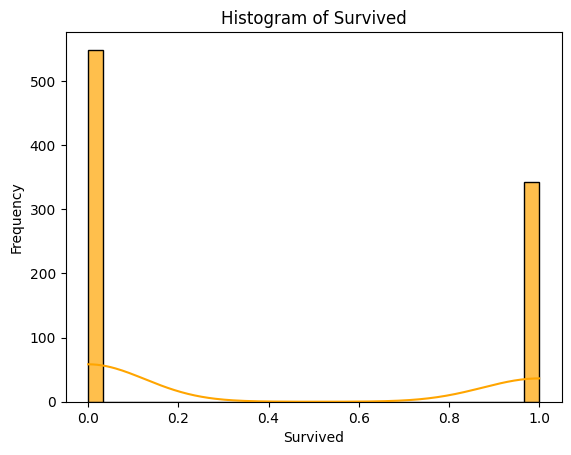

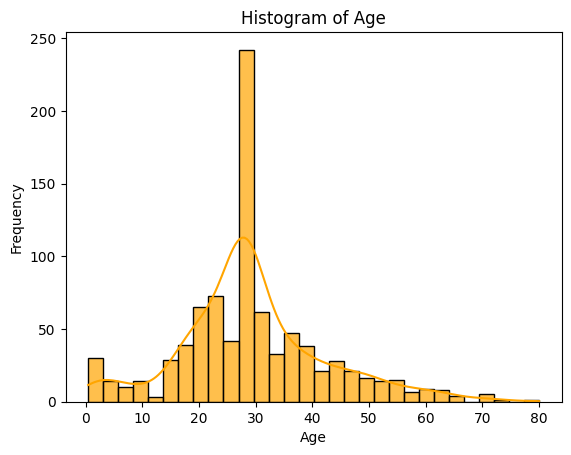

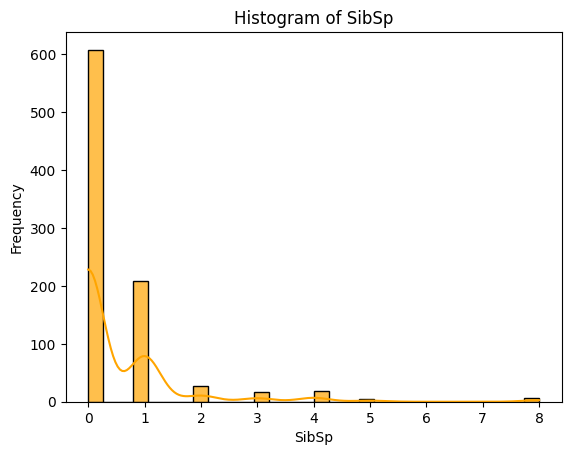

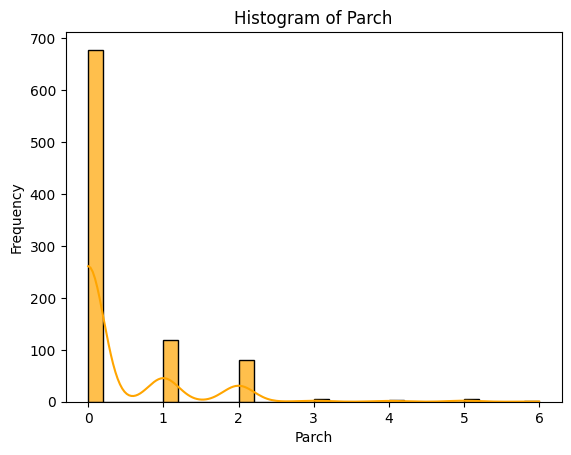

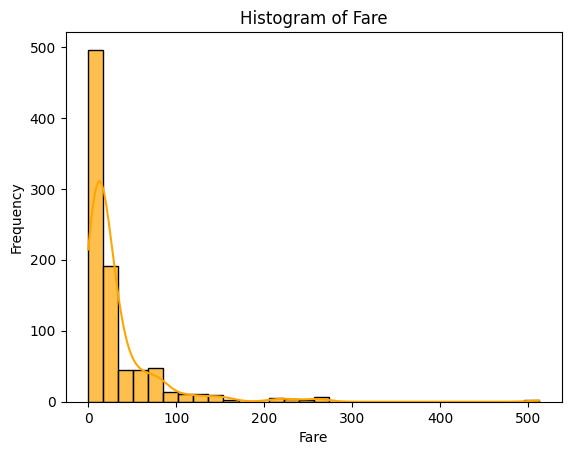

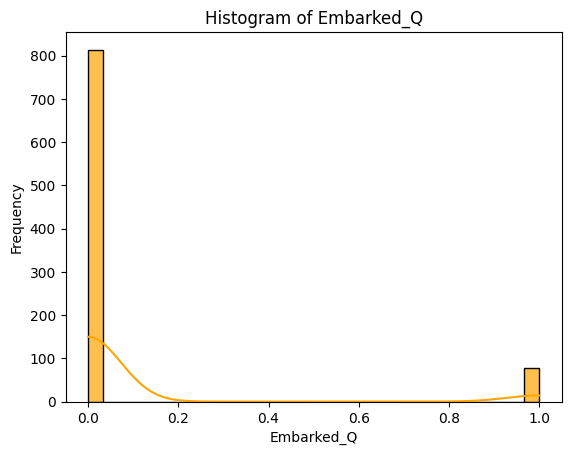

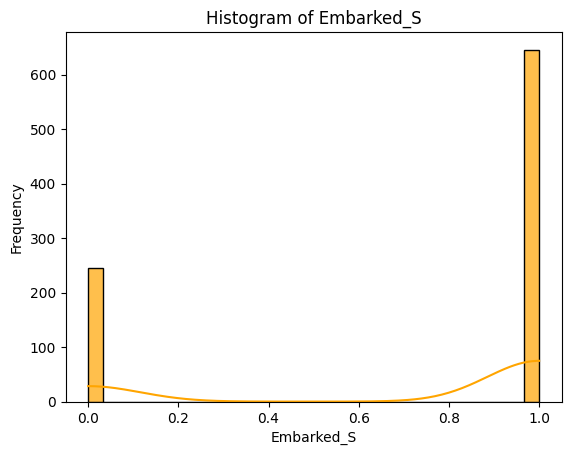

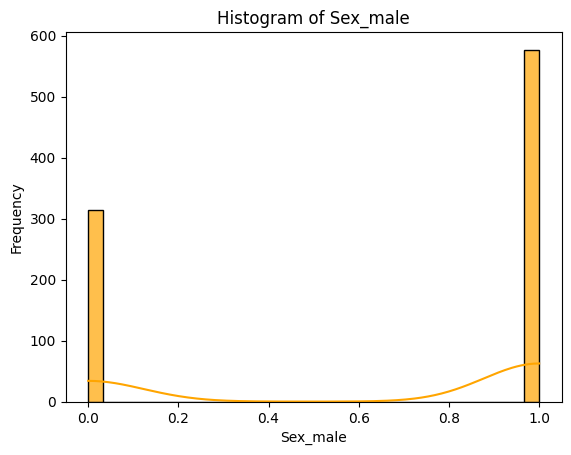

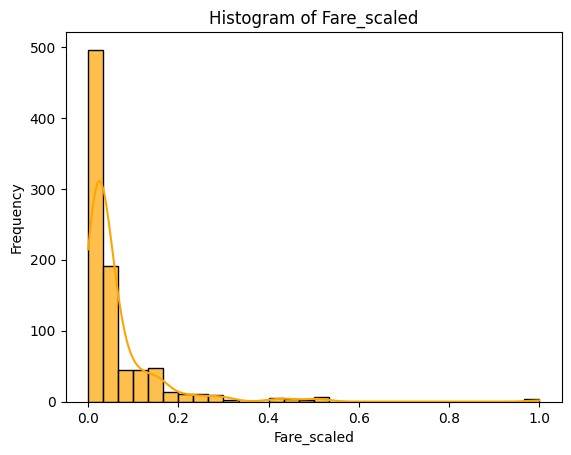

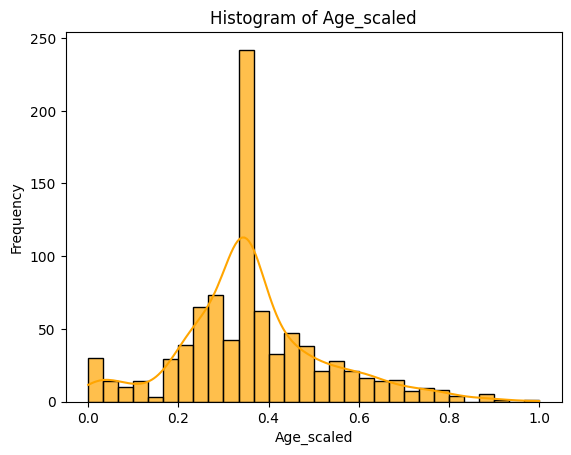

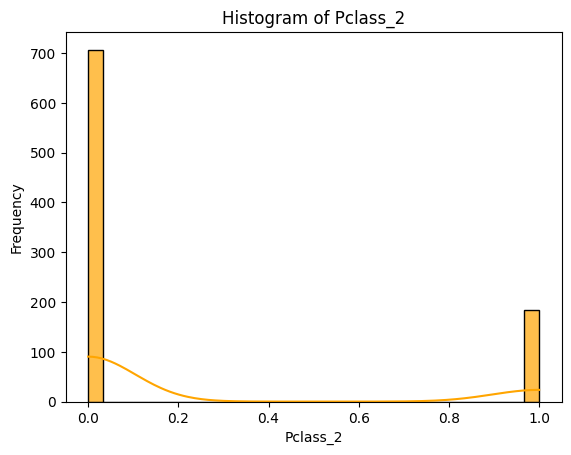

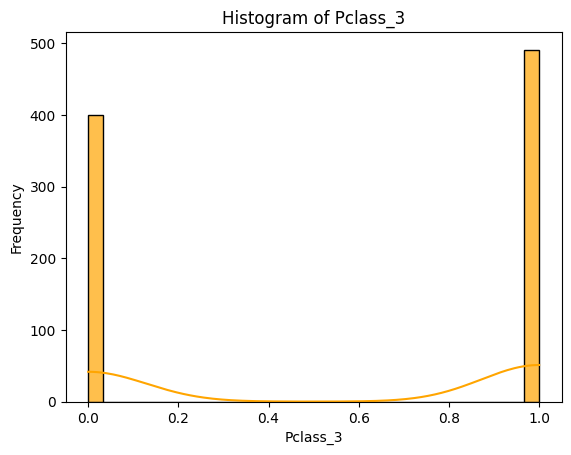

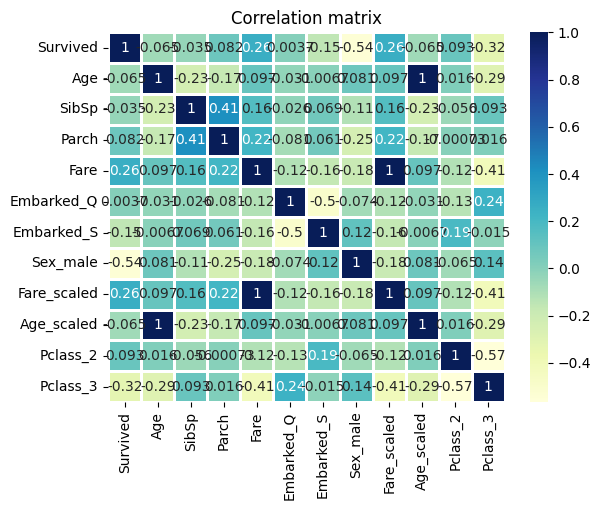

In [98]:
EDA(data)

In [141]:
#Train test split
X = data.drop(['Survived'],axis=1)
Y = data['Survived']
Model = LogisticRegression(random_state=42)
Model.fit(X,Y)

LogisticRegression(random_state=42)

In [138]:
data = data.drop(['Age','Fare'],axis=1)

In [139]:
data.head()

,Survived,SibSp,Parch,Embarked_Q,Embarked_S,Sex_male,Fare_scaled,Age_scaled,Pclass_2,Pclass_3
0,0,1,0,0,1,1,0.014151,0.271174,0,1
1,1,1,0,0,0,0,0.139136,0.472229,0,0
2,1,0,0,0,1,0,0.015469,0.321438,0,1
3,1,1,0,0,1,0,0.103644,0.434531,0,0
4,0,0,0,0,1,1,0.015713,0.434531,0,1


In [111]:
def feature_engineering1(data):
      #IMPUTATION
    #for AGE we can use median imputation as the data is not missing completely at random,
    #  Lets DROP cabin as it has 77% missing values and it is not required for prediction, 
    # lets use mode imputation for embarked as it has 2 missing values

    data['Age'] = data['Age'].fillna(data['Age'].median())
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
    
    # Encoding
     #For gender we can use label encoding
    #For embarked we can use one hot encoding
  
    data = pd.get_dummies(data, columns=['Embarked','Sex','Pclass'], drop_first=True)

    #Converting the boolean columns to numeric
    # Automatically convert all boolean columns to integers (0/1)
    bool_cols = data.select_dtypes(include=['bool']).columns
    data[bool_cols] = data[bool_cols].astype(int)

    #MIN Max scaler to transform the Fare to a particular range to have an unbiased contribution
    scaler = MinMaxScaler()
    data[['Age_scaled','Fare_scaled']] = scaler.fit_transform(data[['Age','Fare']])
    data = data.drop(['Cabin','PassengerId','Name','Ticket','Age','Fare'], axis=1)
    return data

    
    


In [112]:
fe_test  = feature_engineering1(Test_data)

In [127]:
#One missing data in Fare_scaled, lets impute using median 
fe_test['Fare_scaled'] = fe_test['Fare_scaled'].fillna(fe_test['Fare_scaled'].median())


In [128]:
def VIF(data):
    column = ['Age_scaled','SibSp','Parch','Embarked_Q','Embarked_S','Sex_male','Fare_scaled']
    df = data[column]
    vif_data = pd.DataFrame() 
    vif_data['Feature'] = column
    vif_data['VIF'] = [vif(df.values, i) for i in range(df.shape[1])]
    return vif_data 


In [129]:
VIF(fe_test)

,Feature,VIF
0,Age_scaled,4.467207
1,SibSp,1.391928
2,Parch,1.358712
3,Embarked_Q,1.273599
4,Embarked_S,2.816922
5,Sex_male,2.504769
6,Fare_scaled,1.932689


In [148]:
# Ensure test data has the same columns in the same order
fe_test = fe_test[X.columns]
#Testing the model in fe_test dataset
test_predictions = Model.predict(fe_test)
fe_test['Survived_predictions'] = test_predictions


In [154]:
fe_test = fe_test[X.columns]
test_probabilities = Model.predict_proba(fe_test)[:, 1]

In [150]:
# Create submission file
submission = pd.DataFrame({
    'PassengerId': fe_test.index,  # Adjust if PassengerId is a column
    'Survived': fe_test['Survived_predictions']
})
submission.to_csv('submission.csv', index=False)


In [156]:
#Performance metrics 
X = data.drop(['Survived'], axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of class 1 (survived)


In [157]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print metrics
print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")


Model Evaluation Metrics:
Accuracy: 0.7982
Precision: 0.7683
Recall: 0.7079
F1-Score: 0.7368
ROC-AUC Score: 0.8713


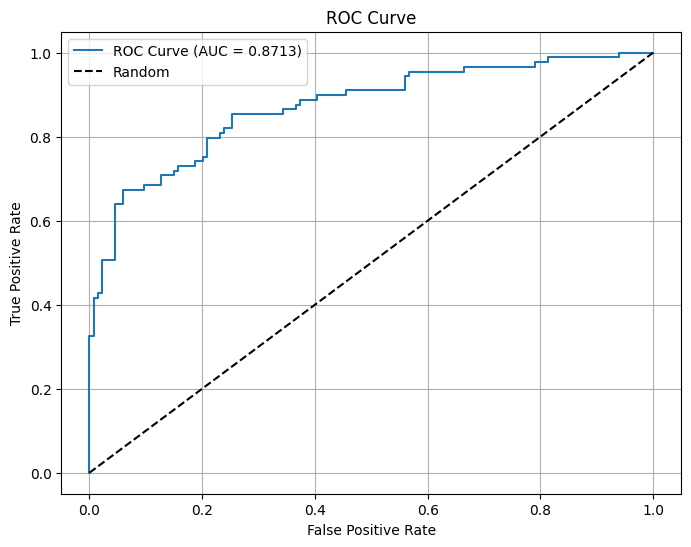

In [160]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# Interpretation of Logistic Regression Results for Titanic Survival Prediction

## a. Interpreting the Coefficients

In logistic regression, the coefficients represent the change in log odds of the target variable (survival) for a one-unit increase in the predictor variable, while holding other variables constant.

Based on the evaluation metrics provided:
- **Accuracy (0.7982)**: The model correctly predicts survival outcomes for approximately 80% of passengers.
- **Precision (0.7683)**: When the model predicts a passenger survived, it's correct about 77% of the time.
- **Recall (0.7079)**: The model correctly identifies about 71% of passengers who actually survived.
- **F1-Score (0.7368)**: This balanced measure of precision and recall shows reasonably good performance.
- **ROC-AUC Score (0.8713)**: This indicates excellent discriminative ability - the model is good at distinguishing between survivors and non-survivors.

While specific coefficient values aren't provided, we can interpret what they would mean:
- Positive coefficients increase survival probability
- Negative coefficients decrease survival probability
- Larger absolute values indicate stronger influence

## b. Significance of Features in Predicting Survival

The ROC curve with an AUC of 0.8713 shows the model has strong predictive power. Based on the Titanic dataset context:

1. **Sex**: Likely a highly significant feature with a strong positive coefficient for females, reflecting the "women and children first" protocol.

2. **Passenger Class (Pclass)**: Probably has negative coefficients for lower classes, indicating decreased survival probability for 3rd class passengers compared to 1st class.

3. **Age**: Likely shows that children had higher survival rates, possibly with a negative coefficient for increasing age.

4. **Family relationships (SibSp, Parch)**: Moderate passengers with family members might show better survival rates than those traveling alone or with very large families.

5. **Fare**: Likely positively correlated with survival, as higher fares indicate higher socioeconomic status and possibly better access to lifeboats.



In [161]:
#Deploy the model 
import joblib
joblib.dump(model, 'logistic_model.pkl')

['logistic_model.pkl']